# EX5 Logistic Regression: Breast Cancer -(Ex3 with better numerical stability)

in Ex3 we used 
model = Sequence(nn.Linear(30,1),nn.Sigmoid)
criterion = RCELoss()
optimizer = opt.Adam(...)

The advantage of **BCEWithLogitsLoss** over using a model with a **Sigmoid** layer followed by **BCELoss** is mainly **numerical stability and computational efficiency**:

1. **Numerical Stability** – When using **BCELoss** with a **Sigmoid** inside the model, the output of the Sigmoid can be very close to **0 or 1**. This leads to **vanishing gradient** problems during backpropagation. In contrast, **BCEWithLogitsLoss** takes raw **logits** directly (before applying Sigmoid) and incorporates the Sigmoid computation internally in a more numerically stable way.

2. **Avoiding Redundant Computations** – If you apply **Sigmoid** inside the model and then use **BCELoss**, there is an **unnecessary** extra computation of the Sigmoid function. **BCEWithLogitsLoss** performs this operation internally in a more optimized manner.

3. **Better Gradients** – Since **BCEWithLogitsLoss** works with raw logits (before Sigmoid), the gradients are **smoother**, which helps in better learning, especially when values are in extreme ranges.

4. **Prevents log(0) Issues** – In **BCELoss**, if the Sigmoid output is exactly **0 or 1**, taking the logarithm inside the loss function can lead to undefined values (**NaN**). **BCEWithLogitsLoss** avoids this problem by operating directly on logits.

### Which One is Better?
- If your model outputs **logits (i.e., no Sigmoid in the final layer)**, you should use **BCEWithLogitsLoss**.  
- If your model outputs **probabilities (i.e., has a Sigmoid in the last layer)**, then you must use **BCELoss**.  

### Recommendation:
**It’s generally better to remove the Sigmoid from the model’s last layer and use BCEWithLogitsLoss** for better stability and accuracy.

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as opt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
dataset = load_breast_cancer()
X,y = dataset.data,dataset.target 

In [3]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)
X_train = torch.from_numpy(X_train.astype(np.float32)).cuda()
X_test = torch.from_numpy(X_test.astype(np.float32)).cuda()
y_train = torch.from_numpy(y_train.astype(np.float32)).cuda()
y_test = torch.from_numpy(y_test.astype(np.float32)).cuda()


In [4]:
model = nn.Linear(30,1).cuda()
J = nn.BCEWithLogitsLoss().cuda()
optimizer= opt.Adam(model.parameters())

In [5]:
EPOCHS = 700
train_losses = []
test_losses= []
train_accuracies = []
test_accuracies = []

In [6]:
def accuracy_func(y_pred, y_true)->float:
    with torch.no_grad():
        a = y_pred.cpu().numpy() > 0
        b =  y_true.cpu().numpy() > 0
        return np.mean(a == b)

In [7]:
for epoch in range(EPOCHS):
    optimizer.zero_grad()

    y_hat = model(X_train)
    loss = J(y_hat,y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    train_acc = accuracy_func(y_hat,y_train)
    train_accuracies.append(train_acc)
    #test loss
    outs_test = model(X_test)
    test_loss = J(outs_test,y_test)
    test_losses.append(test_loss.item())

    #test acc
    test_acc = accuracy_func(outs_test,y_test)
    test_accuracies.append(test_acc)
    #test loss every 50 epochs
    if (epoch + 1) % 50 == 0:
       
        print(f'{epoch +1}/{EPOCHS} train loss: {loss.item():.4f} test loss: {test_loss.item():.4f} train acc: {train_acc.item():.4f} val acc: {test_acc.item():.4f}')
 

50/700 train loss: 0.4467 test loss: 0.4216 train acc: 0.8845 val acc: 0.9043
100/700 train loss: 0.3363 test loss: 0.3198 train acc: 0.9213 val acc: 0.9255
150/700 train loss: 0.2718 test loss: 0.2633 train acc: 0.9449 val acc: 0.9255
200/700 train loss: 0.2298 test loss: 0.2276 train acc: 0.9606 val acc: 0.9468
250/700 train loss: 0.2006 test loss: 0.2031 train acc: 0.9685 val acc: 0.9521
300/700 train loss: 0.1793 test loss: 0.1853 train acc: 0.9711 val acc: 0.9574
350/700 train loss: 0.1630 test loss: 0.1718 train acc: 0.9711 val acc: 0.9574
400/700 train loss: 0.1502 test loss: 0.1614 train acc: 0.9711 val acc: 0.9574
450/700 train loss: 0.1399 test loss: 0.1530 train acc: 0.9764 val acc: 0.9574
500/700 train loss: 0.1314 test loss: 0.1461 train acc: 0.9764 val acc: 0.9574
550/700 train loss: 0.1242 test loss: 0.1404 train acc: 0.9764 val acc: 0.9574
600/700 train loss: 0.1181 test loss: 0.1356 train acc: 0.9790 val acc: 0.9628
650/700 train loss: 0.1128 test loss: 0.1314 train ac

In [8]:

epochs = [i for i in range(len(train_losses))]

In [9]:
len(epochs) == len(test_losses)

True

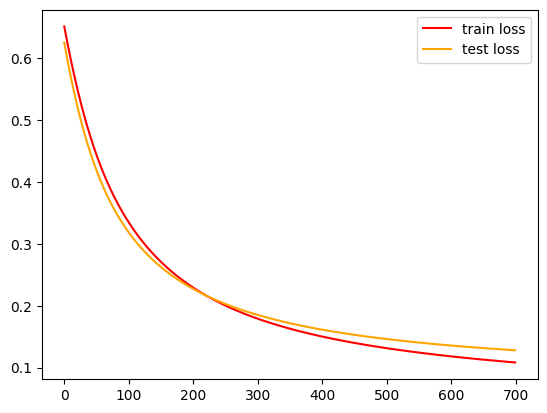

In [10]:
plt.plot(epochs,train_losses,label='train loss',color='red')
plt.plot(epochs,test_losses,label='test loss',color='orange')
plt.legend()


In [11]:
len(epochs)

700

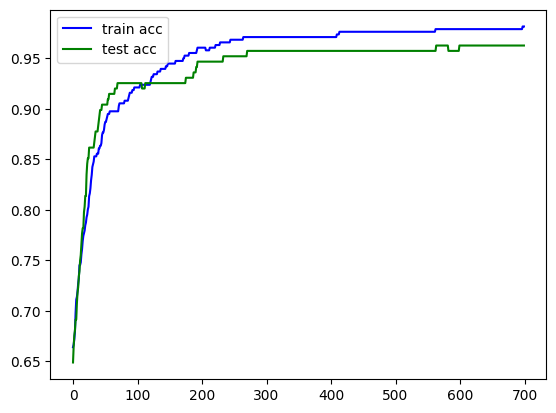

In [12]:
plt.plot(epochs,train_accuracies,label='train acc',color='blue')
plt.plot(epochs,test_accuracies,label='test acc',color='green')
plt.legend()

In [13]:
M = 256
D = 30
K = 10 #classes
model = nn.Linear(M,K)
criterion = nn.CrossEntropyLoss()